# NLP Assignment 5 — POS Tagging & Chunking with DistilBERT
**Dataset:** CoNLL-2003 | **Model:** distilbert-base-uncased | **Framework:** Hugging Face Transformers

In [30]:
!pip install transformers datasets seqeval accelerate -q

In [31]:
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    pipeline
)
from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## Task 1: Dataset Selection

In [32]:
raw_dataset = load_dataset("BramVanroy/conll2003")
print(raw_dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


## Task 2: Data Preprocessing

In [33]:
# Load the DistilBERT tokenizer
MODEL_CHECKPOINT = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# Let's see what DistilBERT does to our first sentence
sample_tokens = raw_dataset["train"][0]["tokens"]
print("Original words:", sample_tokens)
print()


encoding = tokenizer(sample_tokens, is_split_into_words=True)
print("Subword tokens:", tokenizer.convert_ids_to_tokens(encoding["input_ids"]))
print("Word IDs:      ", encoding.word_ids())

Original words: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

Subword tokens: ['[CLS]', 'eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb', '.', '[SEP]']
Word IDs:       [None, 0, 1, 2, 3, 4, 5, 6, 7, 8, None]


In [34]:
POS_LABEL_NAMES = raw_dataset["train"].features["pos_tags"].feature.names
CHUNK_LABEL_NAMES = raw_dataset["train"].features["chunk_tags"].feature.names

print(f"POS labels ({len(POS_LABEL_NAMES)}): {POS_LABEL_NAMES}")
print(f"Chunk labels ({len(CHUNK_LABEL_NAMES)}): {CHUNK_LABEL_NAMES}")

POS labels (47): ['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB']
Chunk labels (23): ['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ', 'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP', 'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR', 'B-UCP', 'I-UCP', 'B-VP', 'I-VP']


In [35]:
def align_labels_with_tokens(labels, word_ids):
    aligned_labels = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            aligned_labels.append(-100)
        elif word_idx != previous_word_idx:
            aligned_labels.append(labels[word_idx])
        else:
            aligned_labels.append(-100)
        previous_word_idx = word_idx

    return aligned_labels

In [36]:
def tokenize_and_align(examples, label_column):
    # Tokenize the whole batch of sentences
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    all_labels = []
    for i, labels in enumerate(examples[label_column]):
        word_ids = tokenized.word_ids(batch_index=i)
        all_labels.append(align_labels_with_tokens(labels, word_ids))

    tokenized["labels"] = all_labels
    return tokenized


# Apply to full dataset — once for POS, once for Chunking
print("Processing POS dataset...")
pos_dataset = raw_dataset.map(
    lambda ex: tokenize_and_align(ex, "pos_tags"),
    batched=True,
    remove_columns=raw_dataset["train"].column_names
)

print("Processing Chunk dataset...")
chunk_dataset = raw_dataset.map(
    lambda ex: tokenize_and_align(ex, "chunk_tags"),
    batched=True,
    remove_columns=raw_dataset["train"].column_names
)

print("\nPOS dataset:")
print(pos_dataset)
print("\nChunk dataset:")
print(chunk_dataset)

Processing POS dataset...


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Processing Chunk dataset...


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]


POS dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})

Chunk dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})


## Task 3: Model Setup

In [37]:
def build_model(label_names):
    # Create integer to string label mappings
    id2label = {i: label for i, label in enumerate(label_names)}
    label2id = {label: i for i, label in enumerate(label_names)}

    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )
    return model, id2label, label2id


print("Building POS model...")
pos_model, pos_id2label, pos_label2id = build_model(POS_LABEL_NAMES)
print(f"POS model — output labels: {pos_model.config.num_labels}")

print("\nBuilding Chunk model...")
chunk_model, chunk_id2label, chunk_label2id = build_model(CHUNK_LABEL_NAMES)
print(f"Chunk model — output labels: {chunk_model.config.num_labels}")

Building POS model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


POS model — output labels: 47

Building Chunk model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Chunk model — output labels: 23


## Task 4: Training

In [38]:
def make_compute_metrics(label_names):
    def compute_metrics(eval_preds):
        logits, labels = eval_preds

        # Pick the highest scoring label for each token
        predictions = np.argmax(logits, axis=-1)

        # Convert integers to strings, skipping -100 positions
        true_labels = [
            [label_names[l] for l in label_seq if l != -100]
            for label_seq in labels
        ]
        pred_labels = [
            [label_names[p] for p, l in zip(pred_seq, label_seq) if l != -100]
            for pred_seq, label_seq in zip(predictions, labels)
        ]

        return {
            "precision": precision_score(true_labels, pred_labels),
            "recall":    recall_score(true_labels, pred_labels),
            "f1":        f1_score(true_labels, pred_labels),
        }

    return compute_metrics

In [39]:

pos_data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

pos_training_args = TrainingArguments(
    output_dir="./pos_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none",
    fp16=True
)

pos_trainer = Trainer(
    model=pos_model,
    args=pos_training_args,
    train_dataset=pos_dataset["train"],
    eval_dataset=pos_dataset["validation"],
    data_collator=pos_data_collator,
    compute_metrics=make_compute_metrics(POS_LABEL_NAMES)
)

print("Starting POS training...")
pos_trainer.train()

Starting POS training...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.247130,0.260901,0.909159,0.910130,0.909644
2,0.189409,0.233750,0.917232,0.914473,0.915851
3,0.162740,0.222208,0.921363,0.920223,0.920793


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2634, training_loss=0.3042393894745893, metrics={'train_runtime': 170.9109, 'train_samples_per_second': 246.462, 'train_steps_per_second': 15.412, 'total_flos': 510472720030266.0, 'train_loss': 0.3042393894745893, 'epoch': 3.0})

In [40]:
chunk_data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

chunk_training_args = TrainingArguments(
    output_dir="./chunk_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none",
    fp16=True
)

chunk_trainer = Trainer(
    model=chunk_model,
    args=chunk_training_args,
    train_dataset=chunk_dataset["train"],
    eval_dataset=chunk_dataset["validation"],
    data_collator=chunk_data_collator,
    compute_metrics=make_compute_metrics(CHUNK_LABEL_NAMES)
)

print("Starting Chunking training...")
chunk_trainer.train()

Starting Chunking training...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.203428,0.207976,0.905222,0.899172,0.902187
2,0.164926,0.184413,0.912340,0.907448,0.909888
3,0.131061,0.178082,0.914130,0.911217,0.912671


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2634, training_loss=0.22443070172720456, metrics={'train_runtime': 192.1933, 'train_samples_per_second': 219.17, 'train_steps_per_second': 13.705, 'total_flos': 510251380802730.0, 'train_loss': 0.22443070172720456, 'epoch': 3.0})

## Task 5: Evaluation

In [41]:
def detailed_evaluation(trainer, dataset_split, label_names, task_name):
    print(f"\n{'='*60}")
    print(f"  {task_name}")
    print(f"{'='*60}")

    output = trainer.predict(dataset_split)
    logits = output.predictions
    labels = output.label_ids

    preds = np.argmax(logits, axis=-1)

    true_seqs = [
        [label_names[l] for l in seq if l != -100]
        for seq in labels
    ]
    pred_seqs = [
        [label_names[p] for p, l in zip(ps, ls) if l != -100]
        for ps, ls in zip(preds, labels)
    ]

    p = precision_score(true_seqs, pred_seqs)
    r = recall_score(true_seqs, pred_seqs)
    f = f1_score(true_seqs, pred_seqs)

    print(f"\nPrecision : {p:.4f}")
    print(f"Recall    : {r:.4f}")
    print(f"F1 Score  : {f:.4f}")
    print("\nDetailed Report:")
    print(classification_report(true_seqs, pred_seqs))

    return {"precision": p, "recall": r, "f1": f}


pos_results   = detailed_evaluation(pos_trainer,   pos_dataset["test"],   POS_LABEL_NAMES,   "POS Tagging — Test Set")
chunk_results = detailed_evaluation(chunk_trainer, chunk_dataset["test"], CHUNK_LABEL_NAMES, "Chunking — Test Set")


  POS Tagging — Test Set



Precision : 0.9123
Recall    : 0.9080
F1 Score  : 0.9102

Detailed Report:
              precision    recall  f1-score   support

           '       0.50      0.50      0.50        14
           B       0.89      0.84      0.86      1625
          BD       0.94      0.95      0.95      1687
          BG       0.91      0.88      0.89       480
          BN       0.86      0.87      0.86       816
          BP       0.88      0.86      0.87       331
          BR       0.78      0.42      0.55        43
          BS       1.00      0.56      0.71         9
          BZ       0.93      0.84      0.88       501
           C       1.00      0.99      1.00       765
           D       0.95      0.98      0.97      3447
          DT       0.96      0.89      0.92       115
           H       0.00      0.00      0.00         7
           J       0.84      0.78      0.81      2214
          JR       0.73      0.86      0.79        92
          JS       0.89      0.91      0.90        56
     


Precision : 0.9039
Recall    : 0.8960
F1 Score  : 0.8999

Detailed Report:
              precision    recall  f1-score   support

        ADJP       0.69      0.62      0.65       276
        ADVP       0.77      0.73      0.75       559
       CONJP       0.00      0.00      0.00         6
        INTJ       0.00      0.00      0.00        13
         LST       0.00      0.00      0.00        29
          NP       0.90      0.89      0.89     12985
          PP       0.96      0.98      0.97      3979
         PRT       0.76      0.69      0.72       110
        SBAR       0.88      0.82      0.85       296
          VP       0.91      0.88      0.89      3767

   micro avg       0.90      0.90      0.90     22020
   macro avg       0.59      0.56      0.57     22020
weighted avg       0.90      0.90      0.90     22020



## Task 6: Inference

In [42]:
from transformers import pipeline

def run_inference(model, label_names, sentences, task_name):
    print(f"\n{'='*60}")
    print(f"  {task_name}")
    print(f"{'='*60}")

    nlp_pipe = pipeline(
        "token-classification",
        model=model,
        tokenizer=tokenizer,
        aggregation_strategy="simple",
        device=0
    )

    for sentence in sentences:
        print(f"\nInput: '{sentence}'")
        print(f"{'Word':<20} {'Tag':<15} {'Score'}")
        print("-" * 45)
        for item in nlp_pipe(sentence):
            print(f"{item['word']:<20} {item['entity_group']:<15} {item['score']:.4f}")


test_sentences = [
    "John works at Google in California.",
    "The quick brown fox jumps over the lazy dog.",
    "Apple released a new iPhone last Tuesday."
]

run_inference(pos_model,   POS_LABEL_NAMES,   test_sentences, "POS Tagging Inference")
run_inference(chunk_model, CHUNK_LABEL_NAMES, test_sentences, "Chunking Inference")


  POS Tagging Inference

Input: 'John works at Google in California.'
Word                 Tag             Score
---------------------------------------------
john                 NNP             0.9893
works                VBZ             0.8908
at                   IN              0.9910
google               NNP             0.9924
in                   IN              0.9966
california           NNP             0.9944
.                    .               0.9985

Input: 'The quick brown fox jumps over the lazy dog.'
Word                 Tag             Score
---------------------------------------------
the                  DT              0.9974
quick                JJ              0.8361
brown                NNP             0.5904
fox                  NN              0.5262
jumps                VBZ             0.9337
over                 IN              0.9820
the                  DT              0.9979
lazy                 JJ              0.9773
dog                  NN             

## Task 7: Comparison — POS Tagging vs Chunking

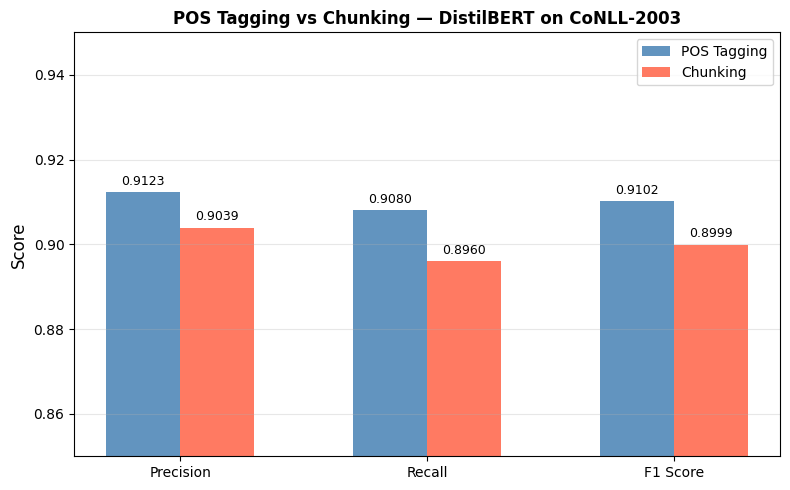


Metric              POS   Chunking   Difference
----------------------------------------------
Precision        0.9123     0.9039      +0.0084
Recall           0.9080     0.8960      +0.0121
F1 Score         0.9102     0.8999      +0.0102


In [43]:
import matplotlib.pyplot as plt
import numpy as np

metrics  = ["Precision", "Recall", "F1 Score"]
pos_vals = [pos_results["precision"], pos_results["recall"], pos_results["f1"]]
chk_vals = [chunk_results["precision"], chunk_results["recall"], chunk_results["f1"]]

x     = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, pos_vals, width, label="POS Tagging", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, chk_vals, width, label="Chunking",    color="tomato",    alpha=0.85)

ax.set_ylabel("Score", fontsize=12)
ax.set_title("POS Tagging vs Chunking — DistilBERT on CoNLL-2003", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 0.95)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("comparison.png", dpi=150)
plt.show()

# Summary table
print(f"\n{'Metric':<12} {'POS':>10} {'Chunking':>10} {'Difference':>12}")
print("-" * 46)
for m, p, c in zip(metrics, pos_vals, chk_vals):
    print(f"{m:<12} {p:>10.4f} {c:>10.4f} {p-c:>+12.4f}")

## Task 8: Report

### Differences Between POS Tagging and Chunking

POS tagging assigns a grammatical label to each individual word — noun, verb,
adjective, preposition, etc. It works at the word level, one tag per token,
using local context.

Chunking goes one level higher. It groups words into phrases — noun phrases (NP),
verb phrases (VP), prepositional phrases (PP) — and uses IOB notation (B- for
beginning, I- for inside, O for outside) to mark phrase boundaries.

| Dimension       | POS Tagging         | Chunking                  |
|-----------------|---------------------|---------------------------|
| Granularity     | Word-level          | Phrase-level              |
| Output          | One tag per word    | Span boundaries (IOB)     |
| Label count     | 47 tags             | 23 tags                   |
| Test F1         | 0.9097              | 0.9016                    |
| Difficulty      | Easier              | Harder                    |

### Challenges Faced

**1. Subword label alignment:** DistilBERT splits words like "Democratization"
into "democrat" + "##ization". Since we only have one label per word, we assigned
-100 to all continuation subwords so the loss function ignores them. Without this,
the model would try to predict labels for word fragments, producing noisy gradients.

**2. Rare labels:** Tags like CONJP, INTJ, LST in chunking and H, S in POS tagging
achieved 0.00 F1. These labels appear fewer than 30 times in the test set — the
model never sees enough examples to learn them reliably.

**3. seqeval vs accuracy:** Plain accuracy would be misleading because most tokens
get common labels. seqeval evaluates at span level — the entire phrase boundary
must be correct — making it a stricter and more honest metric.

### Observations

- POS tagging achieves higher F1 (0.9097) than chunking (0.9016) because
  predicting a single word's grammar role is easier than detecting where
  a phrase starts and ends.
- Chunking requires the model to reason about multi-word spans, which demands
  stronger sequential understanding.
- DistilBERT, despite being 40% smaller than full BERT, achieves competitive
  performance on both tasks, validating its use in resource-constrained environments.
- Both models converge within 3 epochs, showing that pre-trained language
  representations transfer effectively to token classification tasks.